---
title: "Generating your own travel time matrices"
image: image.png
toc: true
execute: 
  enabled: false
---

There are a wide range of options for generating your own travel time matrices, including various travel time APIs. 

You can find an example of how to use the routingpy package, which supports a wide range of APIs, here: https://geographic.hsma.co.uk/mtt_travel_time_apis.html

One good way is the r5py package. 

This takes an output from the open street map project.

Because you're running this locally, you aren't contending with the number of requests you can make to the online services (API rate limits). 

::::{.callout-tip}

If you're interested in using r5py more generally, you may wish to know that it can also handle bus and light rail (e.g. tram) public tranport data in the gtfs format. 

OSM data: https://download.geofabrik.de/europe/united-kingdom/england.html

UK Bus/light rail Data: https://data.bus-data.dft.gov.uk/search/

(at the time of writing, heavy rail data is a bit more of a challenge!)

Some free services like the openrouteservice don't provide public transport routing support by default either. 

:::{.callout-note}

If you're comfortable with the R language, you might also find the [UK2GTFS](https://itsleeds.github.io/UK2GTFS/) package useful

:::

::::





For the purposes of this tutorial, where we're interested in getting a finer-grained matrix for routing problems, we're just going to focus on car data. If you are interested in working out details for multiple travel modalities, have a look at the version of this tutorial in the Location problem section instead [here](../../location/obtaining_travel_time_matrices/index.ipynb).

:::{.callout-warning}
One limitation of r5py is that it requires the install of a JDK. This may be challenging if you are working in an organisation and your IT department has concerns about Java. 

One option may be to use a service like GitHub codespaces to install the required software - a tutorial on this will be released at a later date. 
:::

We'll kick off with a couple of standard imports. 

In [1]:
import datetime
import pandas as pd
import geopandas

Let's start by importing our data to set up a transport network. 

In [2]:
import r5py

transport_network = r5py.TransportNetwork(
    "../../datasets/devon-260422.osm.pbf",
)

First we need to grab our sources (where our nurses will travel from). Because they will go between patient visits, not return to base each time, it's best if we include every possible combination of locations that a nurse could conceivably travel to and from.  

We'll use postcodes centroids for this. 


:::{.callout-note}
We've obtained this by filtering the ONSPD Online Latest Centroids available via the UK government geoportal and downloading the filtered dataset. 

The dataset is available here: [https://geoportal.statistics.gov.uk/datasets/ons::onspd-online-latest-centroids-1](https://geoportal.statistics.gov.uk/datasets/ons::onspd-online-latest-centroids-1)



We've zoomed the map and selected 'filter as map moves' to limit the number of records somewhat, and then ensured 'toggle filters' is selected before downloading. 
:::



:::{.callout-note}
Source: Office for National Statistics licensed under the Open Government Licence v.3.0
Contains OS data © Crown copyright and database right 2026
:::

In [3]:
postcode_centroids = geopandas.read_file("../../datasets/ONSPD_Online_Latest_Centroids_-8786573295356178222.gpkg")

In [4]:
postcode_centroids.head()

,PCD7,PCD8,PCDS,DOINTR,DOTERM,CTY25CD,CED25CD,LAD25CD,WD25CD,PARNCP25CD,...,ICB23CD,OA21CD,LSOA21CD,MSOA21CD,RUC21IND,F_matched_characters,F_matched_parts___part,F_matched_parts___startIndex,GlobalID,geometry
0,PL159TP,PL15 9TP,PL15 9TP,200804,NaN,E99999999,E99999999,E06000052,E05013844,E04011406,...,E54000036,E00095833,E01018974,E02003932,RSF1,None,None,NaN,{2EBC9115-8D94-4842-985E-68713197A179},POINT (231734 91748)
1,PL158WQ,PL15 8WQ,PL15 8WQ,200401,201211,E99999999,E99999999,E06000052,E05013837,E04013094,...,E54000036,E00095782,E01018965,E02003936,RSF1,None,None,NaN,{31A0AD82-62EF-4EFE-BD6F-F731450D774D},POINT (231780 83565)
2,PL157XP,PL15 7XP,PL15 7XP,199712,199906,E99999999,E99999999,E06000052,E05013837,E04013094,...,E54000036,E00095782,E01018965,E02003936,RSF1,None,None,NaN,{B19932C6-DCF5-42CA-A309-2E23E8FB132E},POINT (228455 81741)
3,PL159PY,PL15 9PY,PL15 9PY,198001,200401,E99999999,E99999999,E06000052,E05013837,E04011470,...,E54000036,E00095784,E01018966,E02003936,RSF1,None,None,NaN,{3801CC30-3A0F-4012-B9FA-35896FFD3601},POINT (234571 77542)
4,PL178LB,PL17 8LB,PL17 8LB,198001,NaN,E99999999,E99999999,E06000052,E05013837,E04011589,...,E54000036,E00095787,E01018967,E02003936,RSF1,None,None,NaN,{9BEB33DE-00A1-41E3-8E26-768BD8FB4CD1},POINT (236888 73895)


Let's plot these on an interactive map to check them out. 

<Axes: >

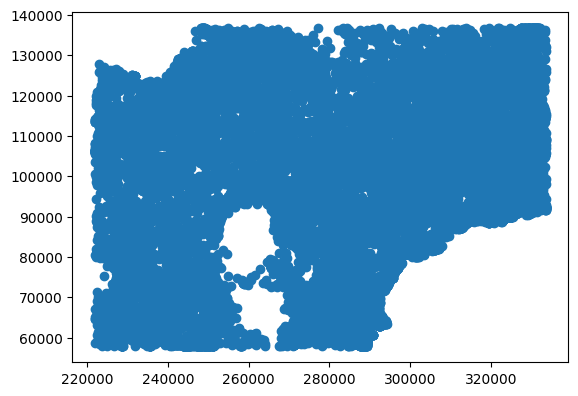

In [5]:
postcode_centroids.plot()

Let's imagine we've been told the team cover TQ postcodes only. 

We use a regular expression here, with the string r"^TQ" matching postcodes that start with TQ - ignoring any where TQ is elsewhere in the postcode. 

So e.g. 

- TQ4 6AH would be included
- EX16 2TQ would not

In [6]:
postcode_centroids_filtered = postcode_centroids[
    postcode_centroids["PCD7"].str.contains(r"^TQ")
    ].copy()

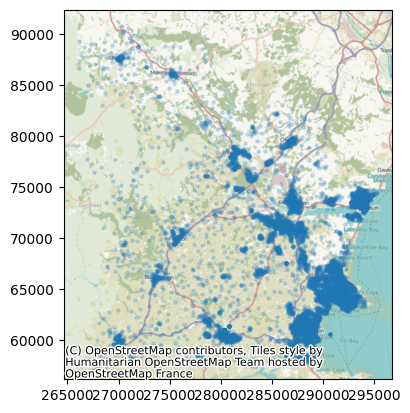

In [7]:
import contextily as cx

ax = postcode_centroids_filtered.plot(alpha=0.2, markersize=5,)

cx.add_basemap(
    ax,
    crs=postcode_centroids_filtered.crs.to_string(),
    )

We can see that we've effectively filtered down our dataset. How many postcodes does this leave? 

In [8]:
len(postcode_centroids_filtered)

10317

How many combinations will this be? 

In [11]:
f"{len(postcode_centroids_filtered)*len(postcode_centroids_filtered):,}"

'106,440,489'

That's quite a lot of combinations! 
Let's see how r5py handles it. 

Let's now convert it from BNH (Northings/Eastings) to latitude and longitude to match our other data (and what r5py expects). 

r5py also requires an 'id' column, so we'll rename our PCD7 (postcode) column to this.

We'll also just get rid of the columns we're not using, and reset the index to tidy up after our earlier filtering. 

In [12]:
postcode_centroids_filtered = (
    postcode_centroids_filtered.to_crs('EPSG:4326').rename(columns={'PCD7':'id'})
    )[["id", "geometry"]].reset_index(drop=True)


In [13]:
postcode_centroids_filtered.head(5)

,id,geometry
0,TQ4 5RS,POINT (-3.57252 50.42742)
1,TQ3 3AH,POINT (-3.57087 50.43668)
2,TQ3 3SR,POINT (-3.58489 50.44288)
3,TQ4 7EN,POINT (-3.58838 50.42337)
4,TQ3 1YD,POINT (-3.56731 50.43675)


## Generating the matrix

### Car travel 

In [ ]:
config_path = prepare_valhalla_network(
    osm_path="../../datasets/devon-260422.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla.json"
)

In [ ]:
travel_time_matrix_car_valhalla = build_time_matrix_valhalla(
    origins_gdf=postcode_centroids_filtered,
    destinations_gdf=postcode_centroids_filtered,
    valhalla_config_path="../../datasets/devon-260422_valhalla.json",
    costing="auto"
)

KeyboardInterrupt: 

In [ ]:
travel_time_matrix_car

,from_id,to_id,travel_time
0,Torbay 006C,North Devon District Hospital,94.0
1,Torbay 006C,Honiton Hospital,47.0
2,Torbay 006C,Tiverton & District Hospital,51.0
3,Torbay 006C,Exmouth Minor Injury Unit,44.0
4,Torbay 006C,Victoria Hospital (Sidmouth),49.0
...,...,...,...
10600,Plymouth 014C,Cumberland Centre (Plymouth),7.0
10601,Plymouth 014C,Derriford Hospital (UTC),11.0
10602,Plymouth 014C,Ilfracombe & District Tyrrell Hospital,NaN
10603,Plymouth 014C,South Molton Hospital,90.0


This isn't in the format lokigi expects - we just need to turn it into a wide format dataframe, where we have one row per source (where our nurses will travel from) and one column per destination (where they might turn up to). 

In [ ]:
travel_time_matrix_car_wide = travel_time_matrix_car.pivot(
    columns="to_id", index="from_id", values="travel_time"
    ).reset_index()

travel_time_matrix_car_wide

to_id,from_id,Cumberland Centre (Plymouth),Dawlish Community Hospital,Derriford Hospital (UTC),Exmouth Minor Injury Unit,Honiton Hospital,Ilfracombe & District Tyrrell Hospital,NHS Walk in Centre (Exeter),Newton Abbot Community Hospital,North Devon District Hospital,South Hams Hospital (Kingsbridge),South Molton Hospital,Tavistock Hospital,Tiverton & District Hospital,Totnes Community Hospital,Victoria Hospital (Sidmouth)
0,East Devon 001A,75.0,44.0,70.0,38.0,16.0,86.0,35.0,47.0,77.0,71.0,55.0,72.0,34.0,56.0,29.0
1,East Devon 001B,71.0,40.0,66.0,33.0,12.0,92.0,31.0,43.0,83.0,67.0,61.0,67.0,40.0,52.0,27.0
2,East Devon 001C,83.0,52.0,77.0,45.0,25.0,104.0,43.0,55.0,94.0,79.0,72.0,79.0,52.0,64.0,39.0
3,East Devon 002A,67.0,36.0,61.0,29.0,3.0,84.0,27.0,39.0,75.0,63.0,53.0,63.0,33.0,48.0,19.0
4,East Devon 002B,67.0,36.0,61.0,29.0,5.0,82.0,27.0,39.0,73.0,63.0,51.0,63.0,30.0,48.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,West Devon 006D,27.0,67.0,16.0,70.0,73.0,103.0,60.0,52.0,90.0,52.0,84.0,11.0,77.0,45.0,75.0
703,West Devon 007A,34.0,74.0,23.0,77.0,81.0,110.0,68.0,60.0,97.0,60.0,92.0,16.0,85.0,52.0,83.0
704,West Devon 007B,34.0,74.0,24.0,76.0,80.0,110.0,67.0,60.0,96.0,60.0,91.0,15.0,84.0,52.0,82.0
705,West Devon 007C,29.0,69.0,18.0,74.0,78.0,109.0,67.0,54.0,96.0,54.0,91.0,17.0,82.0,47.0,79.0


:::{.callout-note}
r5py assumes free flowing traffic at the speed limit - so this might not be overly realistic for traffic! 
:::

Lokigi can't handle missing values in a travel matrix, which might exist here if the time between any two points is over 2 hours or otherwise deemed to be impossible, so let's fill any missing values with a very large travel time. 

In [ ]:
travel_time_matrix_car_wide = travel_time_matrix_car_wide.fillna(9999.0)

We can save this to a csv for convenience if we want to load it in elsewhere later.

In [ ]:
travel_time_matrix_car_wide.to_csv(
    "../../../sample_data/devon_all_postcodes_travel_matrix.csv",
    index=False)